✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)


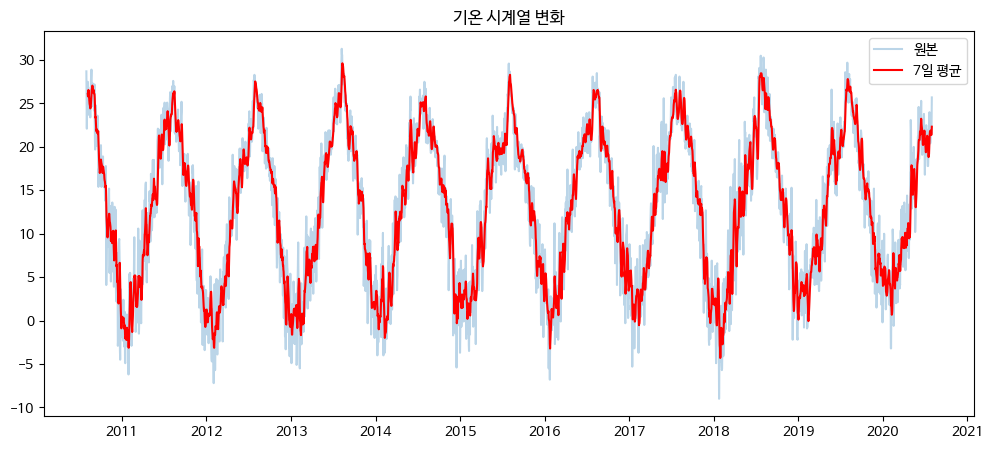

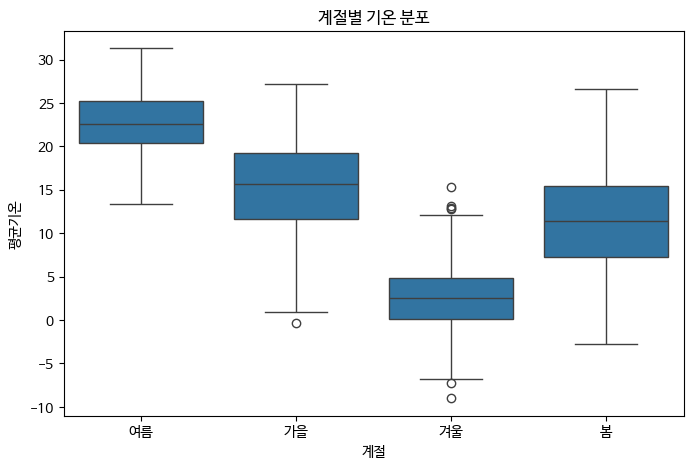

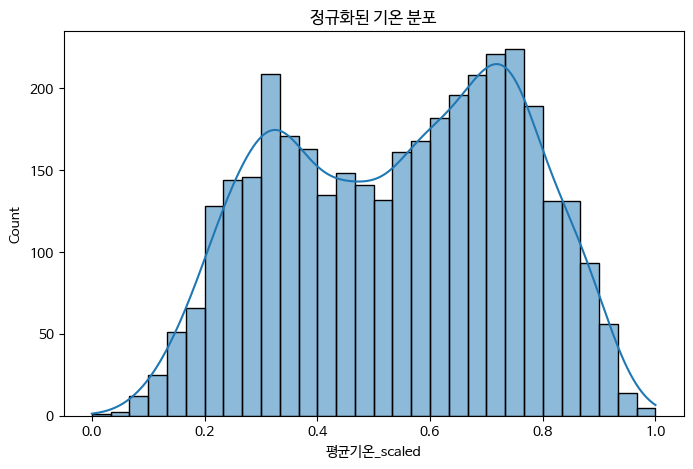

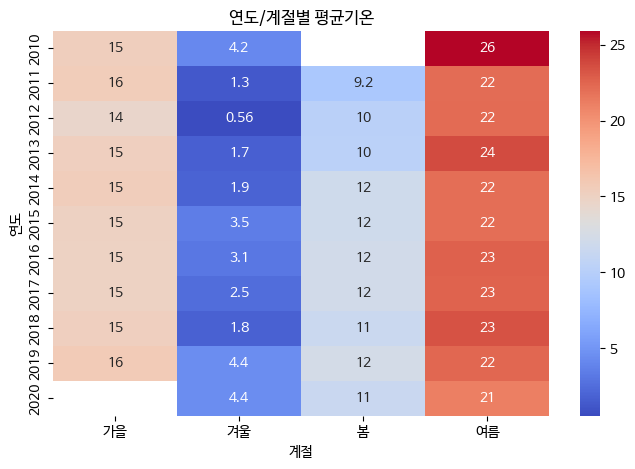

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns # Add this line to import seaborn

# 한글 폰트 설정
def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")


def load_data():
    df = pd.read_csv("weather.csv", encoding='cp949') # encoding 추가
    return df


def preprocess_data(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df = df.sort_values('일시')
    return df


def min_max_scaling(df):
    min_val = df['평균기온'].min()
    max_val = df['평균기온'].max()

    df['평균기온_scaled'] = (df['평균기온'] - min_val) / (max_val - min_val)
    return df


def time_series_processing(df):
    df = df.set_index('일시')
    df['기온_7일평균'] = df['평균기온'].rolling(window=7).mean()
    return df


def add_season(df):
    def get_season(month):
        if month in [3,4,5]:
            return '봄'
        elif month in [6,7,8]:
            return '여름'
        elif month in [9,10,11]: # Fall season added
            return '가을'
        else:
            return '겨울'

    df['계절'] = df.index.month.map(get_season)
    df['연도'] = df.index.year
    return df


def create_pivot_tables(df):
    pivot = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')
    return pivot


def visualize_data(df, pivot):
    # 시계열 그래프
    plt.figure(figsize=(12,5))
    plt.plot(df.index, df['평균기온'], alpha=0.3, label='원본')
    plt.plot(df.index, df['기온_7일평균'], color='red', label='7일 평균')
    plt.legend()
    plt.title("기온 시계열 변화")
    plt.show()


    plt.figure(figsize=(8,5))
    sns.boxplot(x='계절', y='평균기온', data=df.reset_index())
    plt.title("계절별 기온 분포")
    plt.show()


    plt.figure(figsize=(8,5))
    sns.histplot(df['평균기온_scaled'], bins=30, kde=True)
    plt.title("정규화된 기온 분포")
    plt.show()


    plt.figure(figsize=(8,5))
    sns.heatmap(pivot, annot=True, cmap='coolwarm')
    plt.title("연도/계절별 평균기온")
    plt.show()


def save_to_excel(df, pivot):
    with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
        df.to_excel(writer, sheet_name="전체데이터")
        pivot.to_excel(writer, sheet_name="피벗테이블")


def main():
    setup_korean_font() # Call the font setup function
    df = load_data()
    df = preprocess_data(df)
    df = min_max_scaling(df)
    df = time_series_processing(df)
    df = add_season(df)
    pivot = create_pivot_tables(df)
    visualize_data(df, pivot)
    save_to_excel(df, pivot)

main()